In [1]:
import os
os.chdir('/home/ST_Data/saw_results_old')

In [2]:
import sys
import os
from natsort import natsorted
import stereo as st
from stereo.core.ms_data import MSData
from stereo.core.ms_pipeline import slice_generator

/home/wr/anaconda3/envs/stereopy/lib/python3.8/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/home/wr/anaconda3/envs/stereopy/lib/python3.8/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def dna_to_twobit(dna: str) -> int:
/home/wr/anaconda3

In [2]:
import pandas as pd
import scanpy as sc

In [3]:
os.chdir('/home/ST_Data/cellbin')

In [4]:
adata_a4919 = sc.read_h5ad('./A4919_ZD014_Post_SD_liver.h5ad')

In [10]:
adata_a4919.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 251134 stored elements and shape (13060, 32874)>

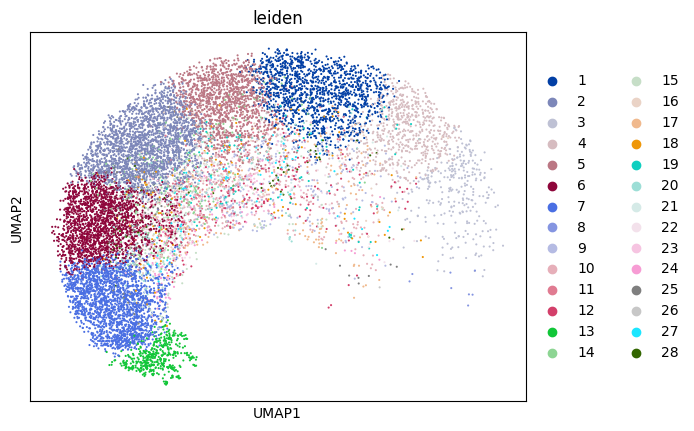

In [6]:
sc.pl.umap(adata_a4919,color='leiden')

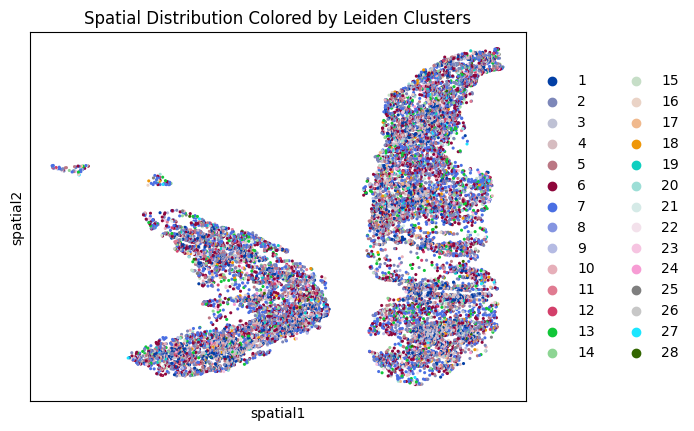

In [7]:
sc.pl.embedding(adata_a4919, 
                basis="spatial", # 指定使用 obsm['spatial'] 中的坐标
                color="leiden",  # 用 obs 中的 'leiden' 列进行着色
                size=20,         # 点的大小
                title="Spatial Distribution Colored by Leiden Clusters",
                show=True)

In [15]:
adata_a4919.obs

,dnbCount,area,total_counts,n_genes_by_counts,pct_counts_mt,leiden,orig.ident,x,y,sample_by_space
29442000820207,12,131,16,13,12.500000,2,sample,6855,6127,A4919
29399051147263,7,71,11,9,18.181818,26,sample,6845,6143,A4919
29364691408866,18,228,23,20,8.695652,5,sample,6837,6114,A4919
29308856834025,9,132,10,10,10.000000,2,sample,6824,6121,A4919
29227252455389,11,152,12,11,8.333333,10,sample,6805,6109,A4919
...,...,...,...,...,...,...,...,...,...,...
32104880555048,17,208,22,20,4.545455,5,sample,7475,17448,A4919
32044751012918,33,344,64,52,3.125000,1,sample,7461,17462,A4919
32023276176393,14,102,25,22,12.000000,5,sample,7456,17417,A4919
31954556699667,3,83,4,4,0.000000,7,sample,7440,17427,A4919


In [5]:
def annotate_split(adata_n,split_x,label1,label2):
    coords = adata_n.obsm["spatial"]
    x = coords[:, 0]
    adata_n.obs["sample_by_space"] = "sample3"
    adata_n.obs.loc[x < split_x, "sample_by_space"] = label1
    adata_n.obs.loc[x >= split_x, "sample_by_space"] = label2
    print(adata_n.obs["sample_by_space"].value_counts())
    import numpy as np
    #coords = adata.cells_matrix["spatial"]
    #labels = adata.cells["sample_by_space"].astype(str).values
    coords = adata_n.obsm["spatial"]
    labels = adata_n.obs["sample_by_space"].astype(str).values
    plt.figure(figsize=(10, 10))
    for lab in np.unique(labels):
        mask = labels == lab
        plt.scatter(coords[mask, 0], coords[mask, 1], s=1, label=lab)
    
    plt.legend(markerscale=6, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Sample split by spatial regions")
    plt.gca().set_aspect("equal")
    plt.tight_layout()
    plt.show()
    return adata_n

In [6]:
import matplotlib.pyplot as plt
def split_tissue(adata):
    coords = adata.obsm["spatial"]
    plt.figure(figsize=(10, 3))
    plt.hist(coords[:, 0], bins=200)
    plt.xlabel("x")
    plt.title("x distribution")
    plt.show()
    plt.figure(figsize=(10, 3))
    plt.hist(coords[:, 1], bins=200)
    plt.xlabel("y")
    plt.title("y distribution")
    plt.show()

In [6]:
adata = sc.read_h5ad("/home/ST_Data/saw_results_old/A4919_1788/outs/analysis/Y40321F6.cellbin_1.0.h5ad")
adata2 = sc.read_h5ad('/home/ST_Data/saw_results_old/A72455_9418/outs/analysis/Y40150F1.cellbin_1.0.h5ad')
adata3 = sc.read_h5ad('/home/ST_Data/saw_results_old/A7229_3571/outs/analysis/Y40150G4.cellbin_1.0.h5ad')
adata4 = sc.read_h5ad('/home/ST_Data/saw_results_old/A1556_4314/outs/analysis/Y40150E9.cellbin_1.0.h5ad')
adata5 = sc.read_h5ad('/home/ST_Data/saw_results_old/A5879_1856/outs/analysis/Y40321L7.cellbin_1.0.h5ad')
adata6 =sc.read_h5ad('/home/ST_Data/saw_results_old/A6994_7396/outs/analysis/Y40051C9.cellbin_1.0.h5ad')

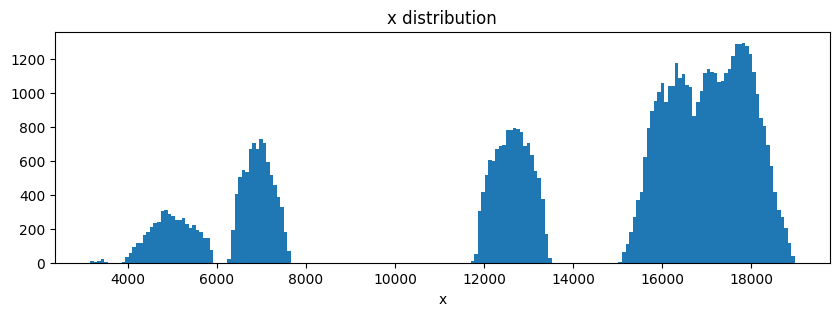

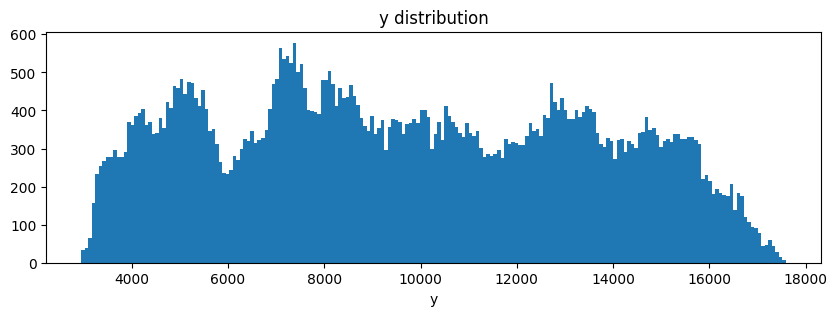

In [7]:
split_tissue(adata)

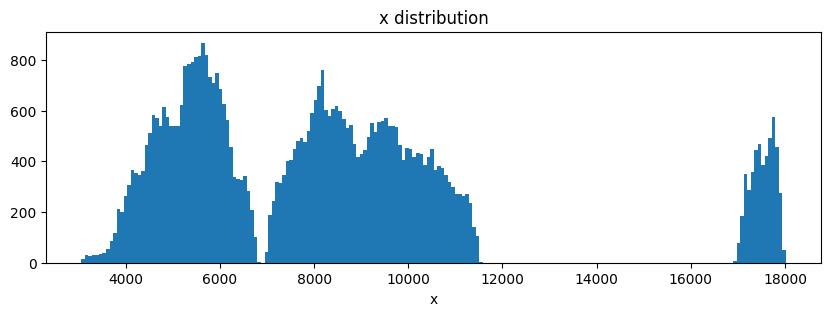

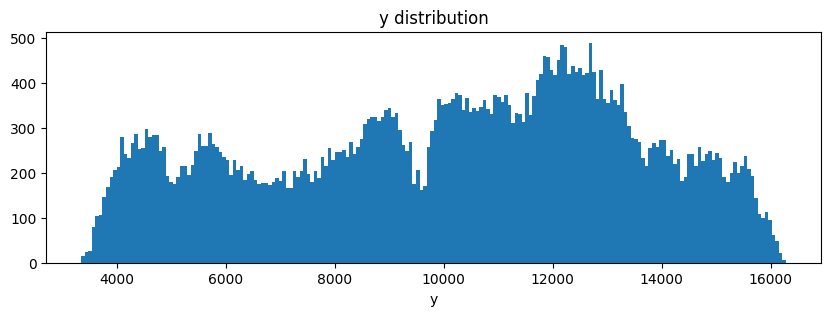

In [8]:
split_tissue(adata2)

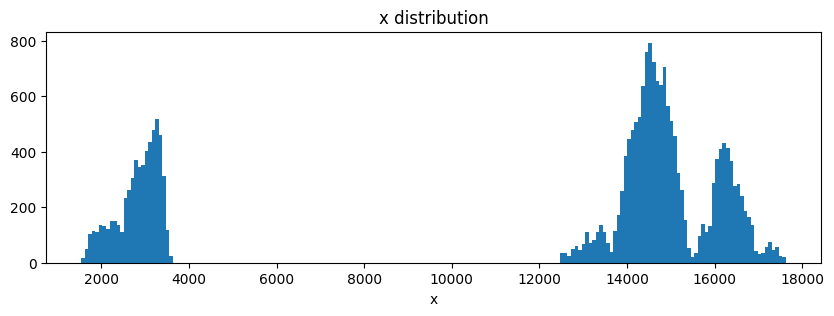

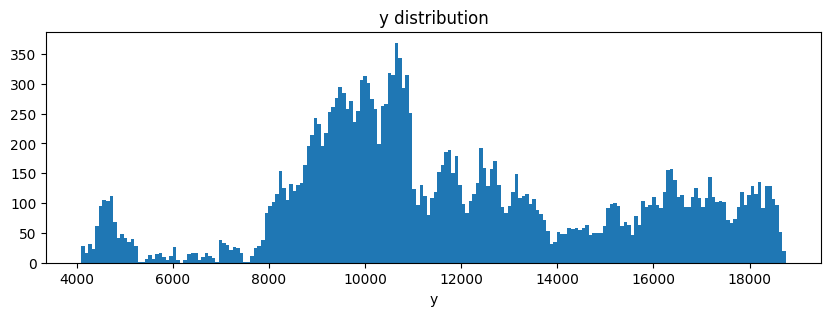

In [9]:
split_tissue(adata3)

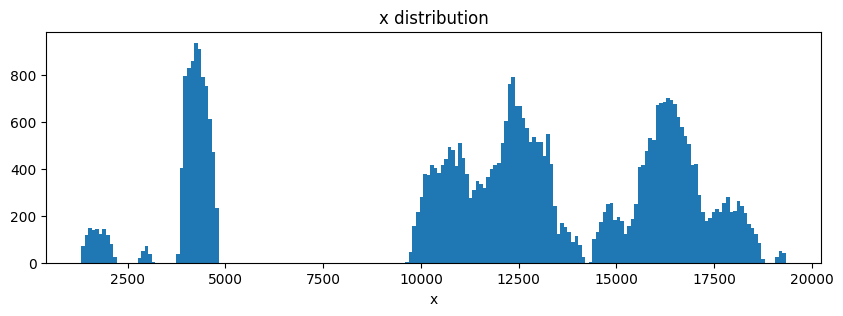

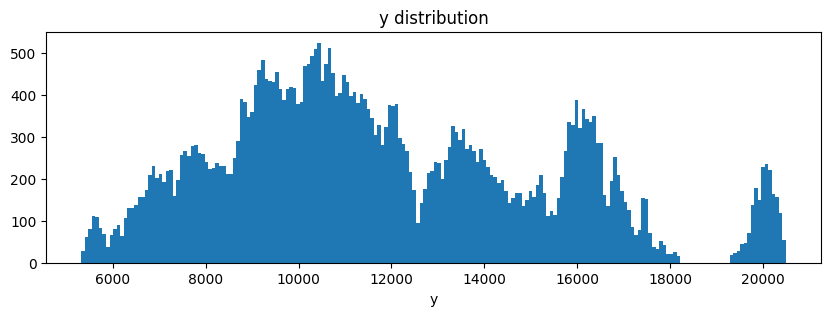

In [10]:
split_tissue(adata4)

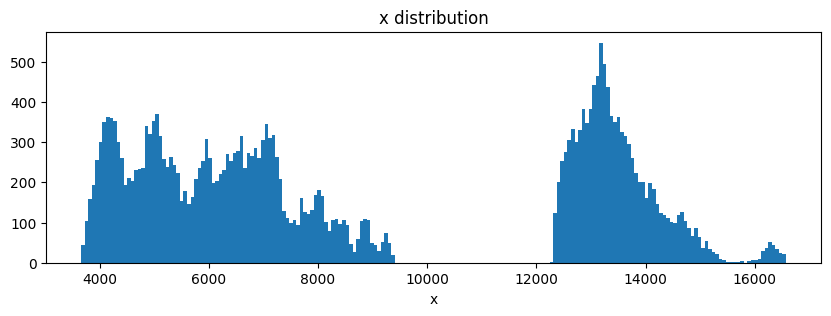

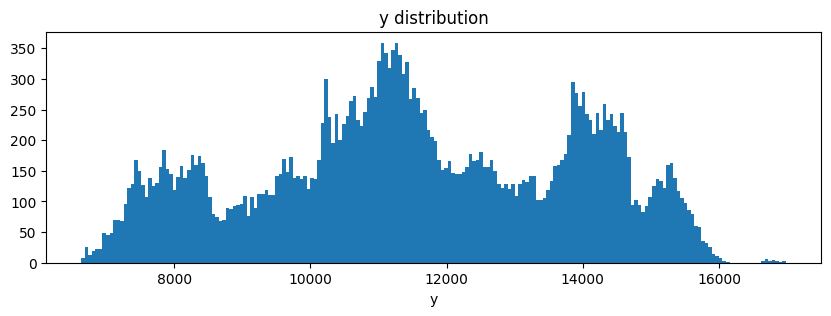

In [11]:
split_tissue(adata5)

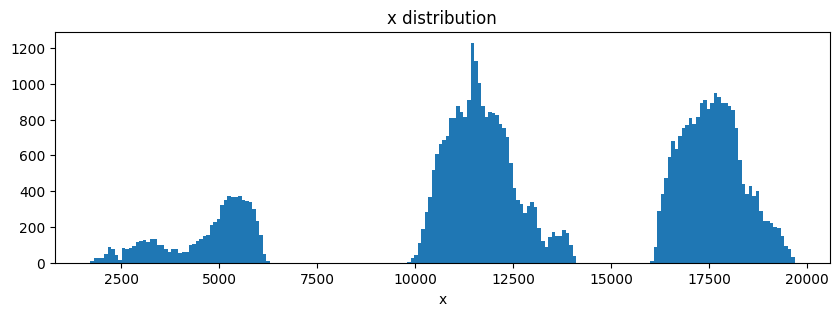

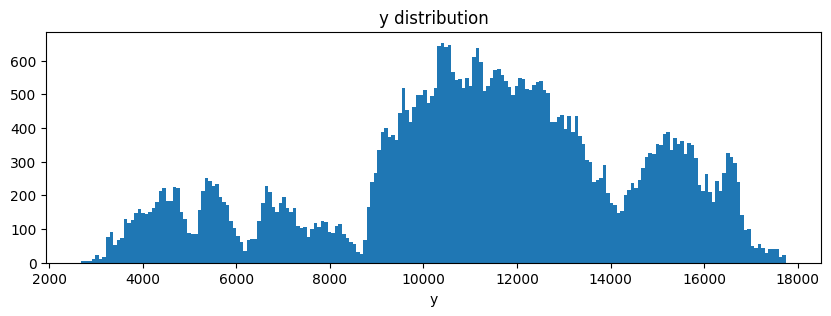

In [12]:
split_tissue(adata6)

sample_by_space
A1788    53005
A4919    13060
Name: count, dtype: int64


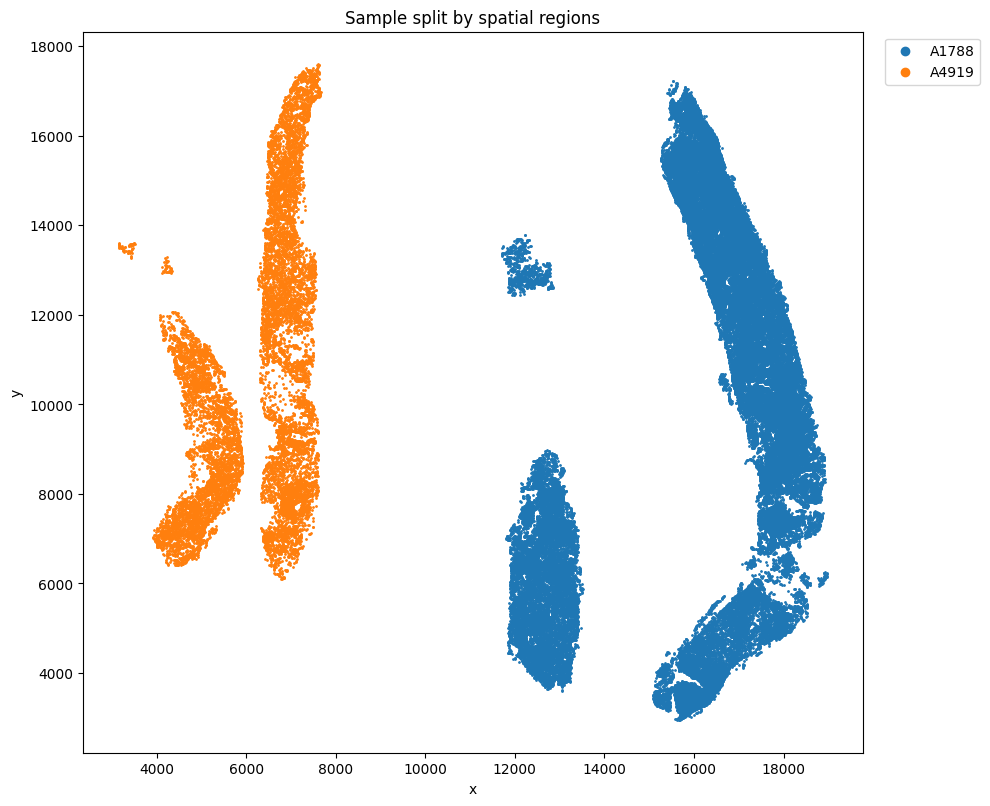

sample_by_space
A72455    47672
A9418      4828
Name: count, dtype: int64


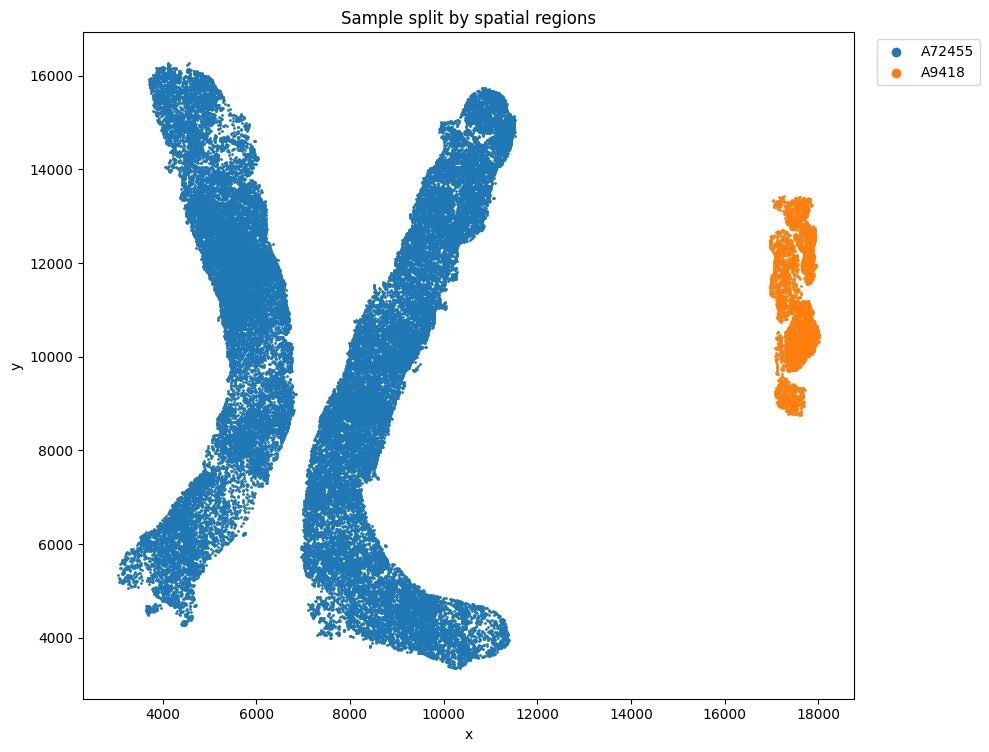

sample_by_space
A3571    15654
A7229     5945
Name: count, dtype: int64


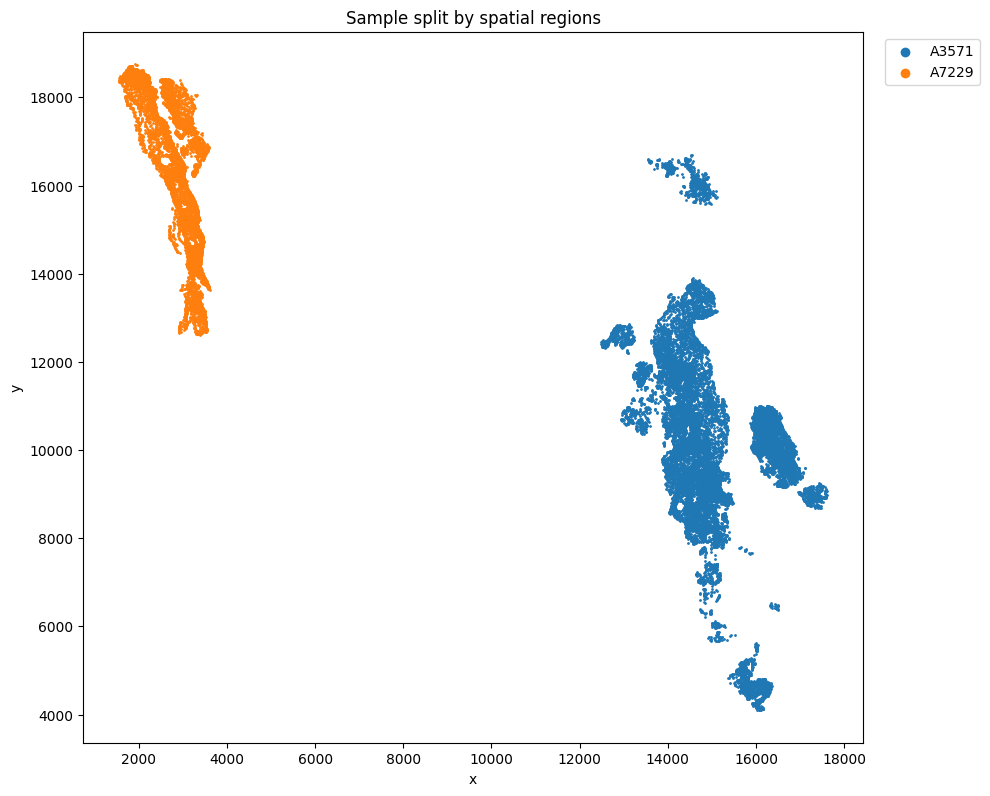

sample_by_space
A4314    35005
A1556     8915
Name: count, dtype: int64


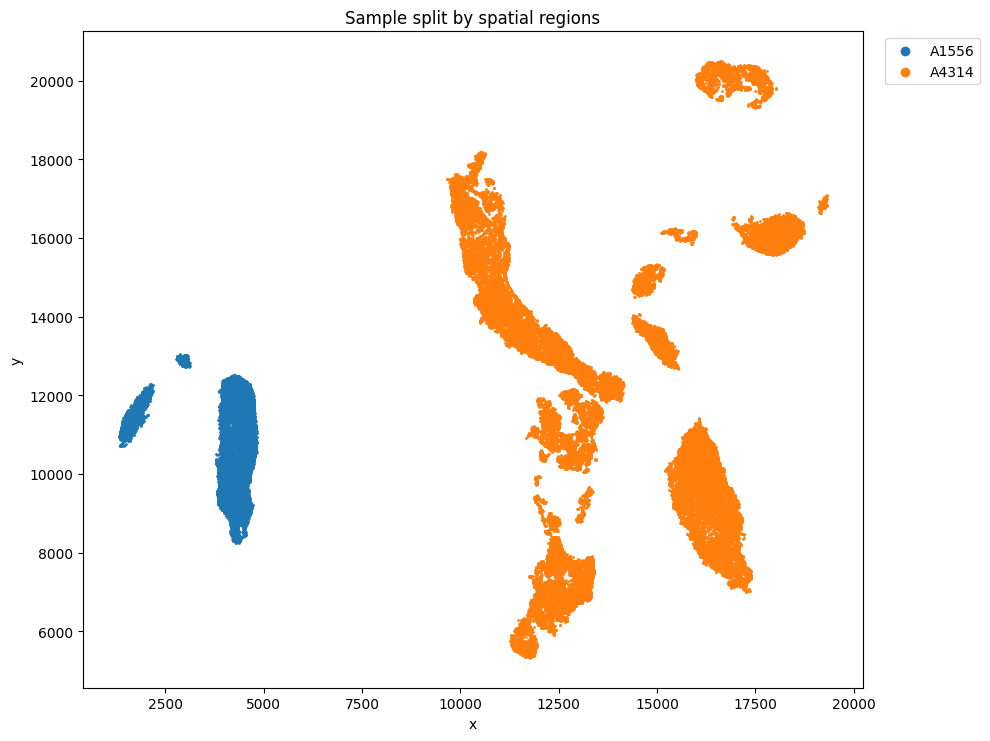

sample_by_space
A5879    17537
A1856    10883
Name: count, dtype: int64


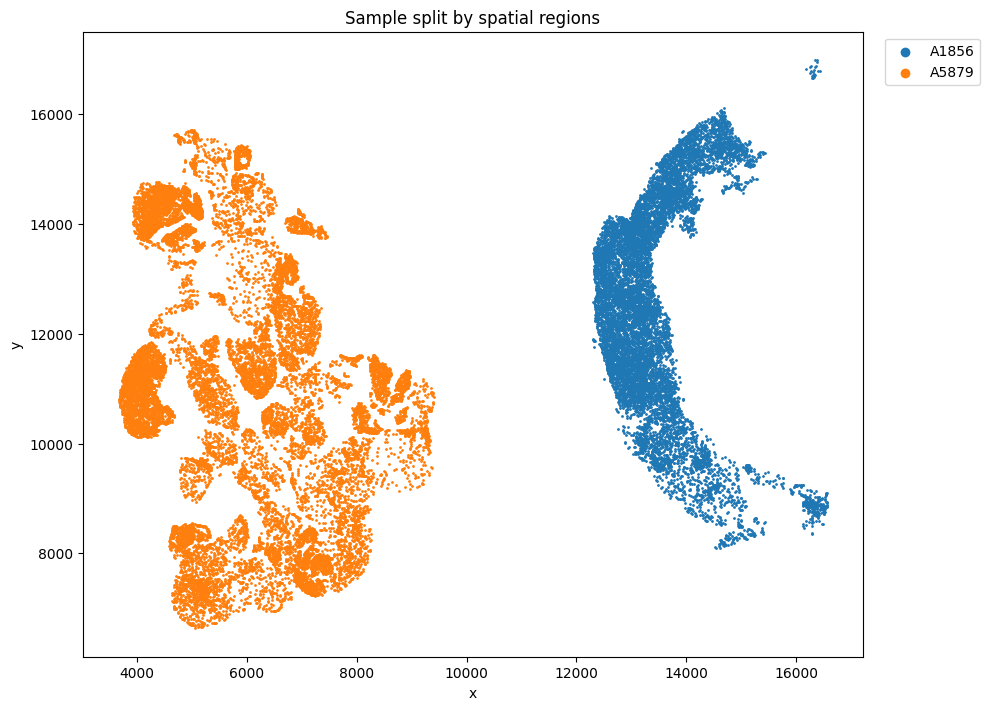

sample_by_space
A7396    45253
A6994     7472
Name: count, dtype: int64


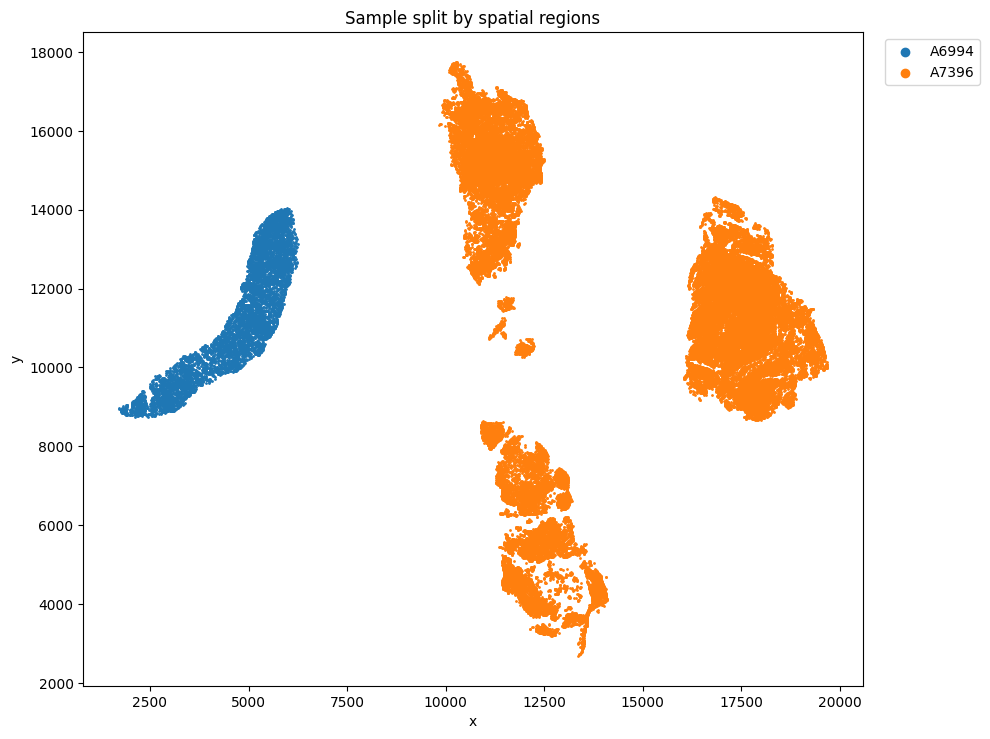

In [13]:
adata= annotate_split(adata,split_x=10000,label1='A4919',label2='A1788')
adata2= annotate_split(adata2,split_x=14000,label1='A72455',label2='A9418')
adata3= annotate_split(adata3,split_x=8000,label1='A7229',label2='A3571')
adata4= annotate_split(adata4,split_x=7500,label1='A1556',label2='A4314')
adata5= annotate_split(adata5,split_x=10000,label1='A5879',label2='A1856')
adata6= annotate_split(adata6,split_x=7500,label1='A6994',label2='A7396')

In [14]:
adata_s1 = adata[adata.obs["sample_by_space"] == "A4919"].copy()
adata_s2 = adata[adata.obs["sample_by_space"] == "A1788"].copy()

In [15]:
adata2_s1 = adata2[adata2.obs["sample_by_space"] == "A72455"].copy()
adata2_s2 = adata2[adata2.obs["sample_by_space"] == "A9418"].copy()

In [16]:
adata3_s1 = adata3[adata3.obs["sample_by_space"] == "A7229"].copy()
adata3_s2 = adata3[adata3.obs["sample_by_space"] == "A3571"].copy()

In [17]:
adata4_s1 = adata4[adata4.obs["sample_by_space"] == "A1556"].copy()
adata4_s2 = adata4[adata4.obs["sample_by_space"] == "A4314"].copy()

In [18]:
adata5_s1 = adata5[adata5.obs["sample_by_space"] == "A5879"].copy()
adata5_s2 = adata5[adata5.obs["sample_by_space"] == "A1856"].copy()

In [19]:
adata6_s1 = adata6[adata6.obs["sample_by_space"] == "A6994"].copy()
adata6_s2 = adata6[adata6.obs["sample_by_space"] == "A7396"].copy()

In [7]:
import warnings
warnings.filterwarnings('ignore')
def sanitize_bytes(obj):
    if isinstance(obj, bytes):
        return obj.decode("utf-8", errors="replace")
    elif isinstance(obj, dict):
        return {k: sanitize_bytes(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [sanitize_bytes(v) for v in obj]
    elif isinstance(obj, tuple):
        return tuple(sanitize_bytes(v) for v in obj)
    else:
        return obj

In [32]:
def find_bytes(obj, path="uns"):
    hits = []
    if isinstance(obj, bytes):
        hits.append(path)
    elif isinstance(obj, dict):
        for k, v in obj.items():
            hits.extend(find_bytes(v, f"{path}/{k}"))
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            hits.extend(find_bytes(v, f"{path}[{i}]"))
    return hits

hits = find_bytes(dict(adata_s1.uns))
print("\n".join(hits[:50]))
print("total hits:", len(hits))

uns/coded_cell_block/L0/0_0
uns/coded_cell_block/L0/0_1
uns/coded_cell_block/L0/0_2
uns/coded_cell_block/L0/0_3
uns/coded_cell_block/L0/1_0
uns/coded_cell_block/L0/1_1
uns/coded_cell_block/L0/1_2
uns/coded_cell_block/L0/1_3
uns/coded_cell_block/L0/2_0
uns/coded_cell_block/L0/2_1
uns/coded_cell_block/L0/2_2
uns/coded_cell_block/L0/3_0
uns/coded_cell_block/L0/3_1
uns/coded_cell_block/L0/3_2
uns/coded_cell_block/L0/3_3
total hits: 15


In [8]:
def find_key(obj, target="0_0", path="uns"):
    out = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            p = f"{path}/{k}"
            if str(k) == target:
                out.append((p, type(v), v[:60] if isinstance(v, bytes) else v))
            out.extend(find_key(v, target=target, path=p))
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            out.extend(find_key(v, target=target, path=f"{path}[{i}]"))
    return out

print(find_key(dict(adata_s1.uns), "0_0"))

NameError: name 'adata_s1' is not defined

In [36]:
adata_s1.uns = sanitize_bytes(dict(adata_s1.uns))
adata_s1.write_h5ad('/home/ST_Data/A4919_ZD014_Post_SD_liver.h5ad')
adata_s2.uns = sanitize_bytes(dict(adata_s2.uns))
adata_s2.write_h5ad('/home/ST_Data/A1788_ZD017_Pre_SD_liver.h5ad')
adata2_s1.uns = sanitize_bytes(dict(adata2_s1.uns))
adata2_s1.write_h5ad('/home/ST_Data/A72455_ZD014_Pre_SD_liver.h5ad')
adata2_s2.uns = sanitize_bytes(dict(adata2_s2.uns))
adata2_s2.write_h5ad('/home/ST_Data/A9418_ZD012_Pre_dead_pancreas.h5ad')
adata3_s1.uns = sanitize_bytes(dict(adata3_s1.uns))
adata3_s1.write_h5ad('/home/ST_Data/A7229_ZD017_Post_SD_Esophagus.h5ad')
adata3_s2.uns = sanitize_bytes(dict(adata3_s2.uns))
adata3_s2.write_h5ad('/home/ST_Data/A3571_ZD020_Pre_PR_Liver.h5ad')
adata4_s1.uns = sanitize_bytes(dict(adata4_s1.uns))
adata4_s1.write_h5ad('/home/ST_Data/A1556_ZD016_Pre_PR_Ovary.h5ad')
adata4_s2.uns = sanitize_bytes(dict(adata4_s2.uns))
adata4_s2.write_h5ad('/home/ST_Data/A4314_ZD015_Pre_PR_PLN.h5ad')
adata5_s1.uns = sanitize_bytes(dict(adata5_s1.uns))
adata5_s1.write_h5ad('/home/ST_Data/A5879_ZD003_Post_PR_Stomach.h5ad')
adata5_s2.uns = sanitize_bytes(dict(adata5_s2.uns))
adata5_s2.write_h5ad('/home/ST_Data/A1856_ZD015_Post_PR_PLN.h5ad')
adata6_s1.uns = sanitize_bytes(dict(adata6_s1.uns))
adata6_s1.write_h5ad('/home/ST_Data/A6994_ZD016_Post_PR_PM.h5ad')
adata6_s2.uns = sanitize_bytes(dict(adata6_s2.uns))
adata6_s2.write_h5ad('/home/ST_Data/A7369_ZD015_Post_Relapse_Esophagus.h5ad')

... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical
... storing 'sample_by_space' as categorical


In [34]:
def sanitize_bytes(obj):
    if isinstance(obj, bytes):
        return obj.decode("utf-8", errors="replace")
    elif isinstance(obj, dict):
        return {k: sanitize_bytes(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [sanitize_bytes(v) for v in obj]
    elif isinstance(obj, tuple):
        return tuple(sanitize_bytes(v) for v in obj)
    else:
        return obj

adata_s1.uns = sanitize_bytes(dict(adata_s1.uns))

In [35]:
adata_s1.write_h5ad('/home/ST_Data/A4919_ZD014_Post_SD_liver.h5ad')

In [52]:
import scanpy as sc
adata_s1=sc.read_h5ad('/home/ST_Data/bin50/A4919_ZD014_Post_SD_liver.h5ad')

In [54]:
adata_s1.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 7572 × 30703
    obs: 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'leiden', 'orig.ident', 'x', 'y', 'sample_by_space'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bin_size', 'bin_type', 'gene_exp_leiden', 'hvg', 'key_record', 'leiden_resolution', 'merged', 'neighbors', 'omics', 'pca_variance_ratio', 'rank_genes_groups', 'resolution', 'result_keys', 'sn'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'log1p'
    obsp: 'connectivities', 'distances'>

In [55]:
FINAL_LABEL_KEYS=['leiden','sample_by_space']

In [56]:
adata_s1.obs[FINAL_LABEL_KEYS]

,leiden,sample_by_space
13314398631050,9,A4919
13314398631100,9,A4919
13314398631150,9,A4919
13314398631200,9,A4919
13529146995800,9,A4919
...,...,...
32856499831450,9,A4919
32856499831500,9,A4919
32856499831900,9,A4919
32856499831950,9,A4919


In [82]:
import scanpy as sc
adata3_s2=sc.read_h5ad('/home/ST_Data/bin50/A3571_ZD020_Pre_PR_Liver.h5ad')

In [51]:
adata_s1.raw.X

<Compressed Sparse Row sparse matrix of dtype 'uint32'
	with 1552751 stored elements and shape (7572, 30703)>

In [50]:
adata_s1

AnnData object with n_obs × n_vars = 7572 × 30703
    obs: 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'leiden', 'orig.ident', 'x', 'y', 'sample_by_space'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bin_size', 'bin_type', 'gene_exp_leiden', 'hvg', 'key_record', 'leiden_resolution', 'merged', 'neighbors', 'omics', 'pca_variance_ratio', 'rank_genes_groups', 'resolution', 'result_keys', 'sn'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'log1p'
    obsp: 'connectivities', 'distances'

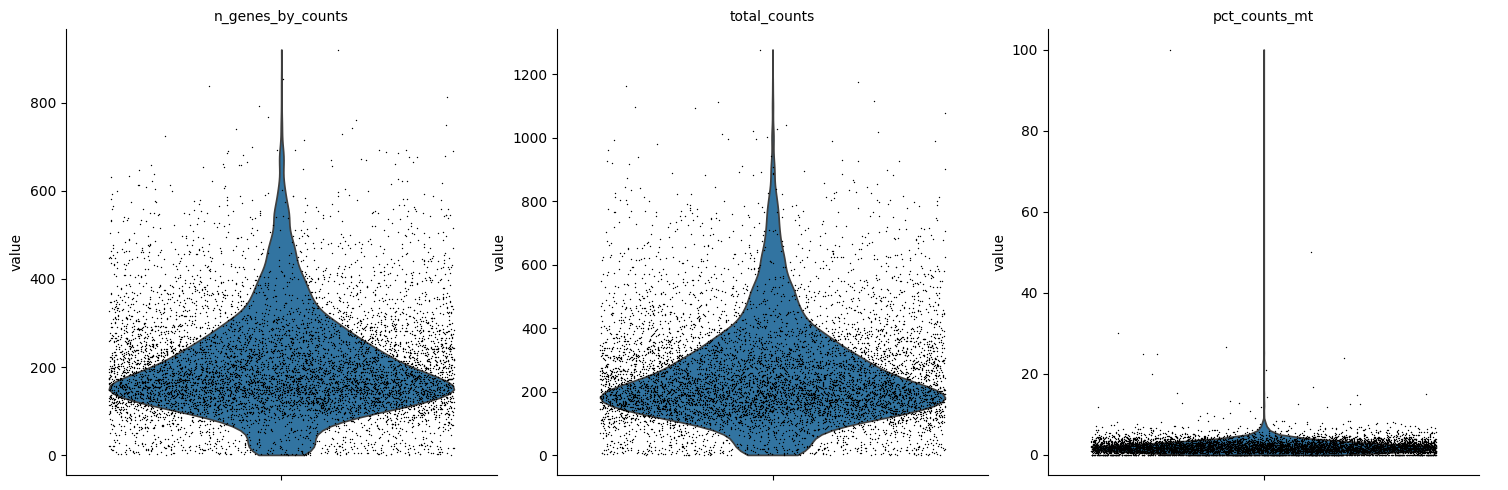

In [44]:
sc.pl.violin(
    adata_s1,
    ['n_genes_by_counts', "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [44]:
adata_s1.layers["counts"] = adata_s1.X.copy()
sc.pp.normalize_total(adata_s1, target_sum=1e4)
sc.pp.log1p(adata_s1)

In [45]:
sc.pp.highly_variable_genes(
    adata_s1,
    n_top_genes=1000,
    flavor="seurat_v3",
    layer="counts"
)

In [44]:
#pip install --user scikit-misc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 7.4 MB/s eta 0:00:0000:010:01
Note: you may need to restart the kernel to use updated packages.


In [15]:
adata_s1.uns_keys

<bound method AnnData.uns_keys of AnnData object with n_obs × n_vars = 13060 × 32874
    obs: 'dnbCount', 'area', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'leiden', 'orig.ident', 'x', 'y', 'sample_by_space'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'bin_size', 'bin_type', 'coded_cell_block', 'gene_exp_leiden', 'hvg', 'key_record', 'leiden_resolution', 'merged', 'neighbors', 'omics', 'pca_variance_ratio', 'rank_genes_groups', 'resolution', 'result_keys', 'sn', 'log1p'
    obsm: 'X_pca', 'X_umap', 'cell_border', 'spatial'
    layers: 'log1p', 'counts'
    obsp: 'connectivities', 'distances'>

In [46]:
sc.pp.scale(adata_s1, max_value=10)
sc.tl.pca(adata_s1, svd_solver="arpack")
sc.pp.neighbors(adata_s1, n_neighbors=40, n_pcs=20)
sc.tl.umap(adata_s1,)
sc.tl.leiden(adata_s1, resolution=0.2, key_added="leiden")

In [58]:
sc.tl.leiden(adata_s1, resolution=0.3, key_added="leiden")

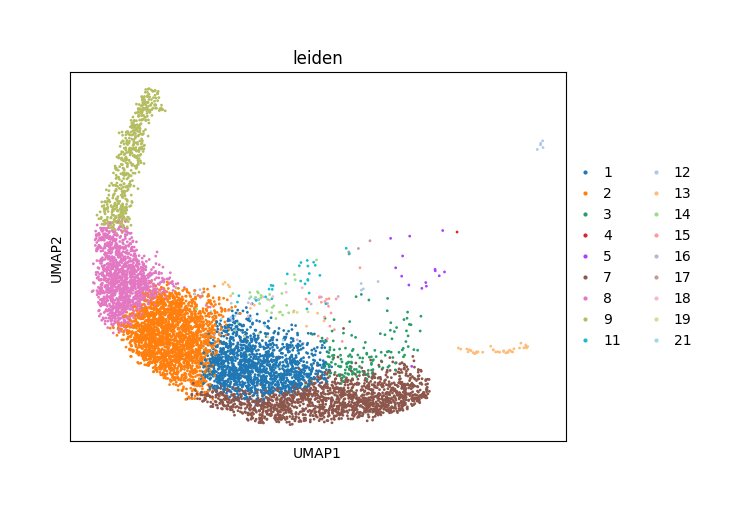

In [78]:
sc.pl.umap(adata_s1,color="leiden")
#adata_s1.obs_keys

In [8]:
def id2symbol(adata_s1):
    adata_symbol = adata_s1.copy()
    adata_symbol = adata_s1.copy()
    # 用 real_gene_name 替代 var_names
    adata_symbol.var_names = adata_symbol.var["real_gene_name"].astype(str)
    # 去重，避免重复symbol报错
    adata_symbol.var_names_make_unique()
    return(adata_symbol)

In [92]:
#pip uninstall scvi-tools[cuda] -y

Found existing installation: scvi-tools 0.14.6
Uninstalling scvi-tools-0.14.6:
  Successfully uninstalled scvi-tools-0.14.6
Note: you may need to restart the kernel to use updated packages.


In [23]:
ref.var

,vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_mean,vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_variance,vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_variance.expected,vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_variance.standardized,vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_variable,vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_rank,vf_vst_counts.ZD013_after_ZD013_S2_ZL_filtered_feature_bc_matrix_mean,vf_vst_counts.ZD013_after_ZD013_S2_ZL_filtered_feature_bc_matrix_variance,vf_vst_counts.ZD013_after_ZD013_S2_ZL_filtered_feature_bc_matrix_variance.expected,vf_vst_counts.ZD013_after_ZD013_S2_ZL_filtered_feature_bc_matrix_variance.standardized,...,vf_vst_counts.ZD020_before_ZD020_S1_ZL_filtered_feature_bc_matrix_variable,vf_vst_counts.ZD020_before_ZD020_S1_ZL_filtered_feature_bc_matrix_rank,vf_vst_counts_mean,vf_vst_counts_variance,vf_vst_counts_variance.expected,vf_vst_counts_variance.standardized,vf_vst_counts_variable,vf_vst_counts_rank,var.features,var.features.rank
MTND2P28,0.083257,0.102015,0.137310,0.742954,0,-2147483648,0.220586,0.288051,0.428307,0.672535,...,0,-2147483648,0.527621,8.656990,0.983160,8.805267,1,33,MTND2P28,33
HES4,0.651147,9.563213,2.776377,3.444493,1,274,0.087692,0.267285,0.139970,1.909590,...,1,2944,0.300830,0.976213,0.481327,2.028171,1,424,HES4,424
ISG15,1.036368,25.291386,6.191524,3.292787,1,303,0.512011,2.095658,1.429992,1.465503,...,0,-2147483648,2.904606,35.632325,12.826647,2.777992,1,230,ISG15,230
AL645608.8,0.000663,0.000662,0.000787,0.841364,0,-2147483648,0.000194,0.000194,0.000210,0.921764,...,2,-2147483648,0.000618,0.000794,0.000707,1.122344,0,-2147483648,NA,-2147483648
TNFRSF18,0.124016,0.377576,0.221338,1.705884,1,1077,0.157885,0.447334,0.280442,1.595104,...,0,-2147483648,0.011913,0.019186,0.015984,1.200283,0,-2147483648,NA,-2147483648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC116025.1,NaN,NaN,NaN,NaN,2,-2147483648,NaN,NaN,NaN,NaN,...,2,-2147483648,0.000000,0.000000,0.000000,0.000000,0,-2147483648,NA,-2147483648
MIR4253,NaN,NaN,NaN,NaN,2,-2147483648,NaN,NaN,NaN,NaN,...,1,2068,0.000176,0.000353,0.000187,1.000255,0,-2147483648,NA,-2147483648
OR6C70,NaN,NaN,NaN,NaN,2,-2147483648,NaN,NaN,NaN,NaN,...,1,2079,0.000000,0.000000,0.000000,0.000000,0,-2147483648,NA,-2147483648
AC011990.1,NaN,NaN,NaN,NaN,2,-2147483648,NaN,NaN,NaN,NaN,...,1,2547,0.000000,0.000000,0.000000,0.000000,0,-2147483648,NA,-2147483648


In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc

In [1]:
#USE SCVI KERNEL
import scvi
from scipy import sparse

/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ref = sc.read_h5ad('/home/ST_Data/scData/RNA/TAMC.h5ad')

/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [17]:
print(ref.raw.var_names[:5])

Index(['WASH7P', 'MIR6859-1', 'AL627309.6', 'AL627309.7', 'AL627309.5'], dtype='object')


In [22]:
st1_raw.raw.X

<Compressed Sparse Row sparse matrix of dtype 'uint32'
	with 1552751 stored elements and shape (7572, 30703)>

In [ ]:
import torch

In [28]:
import os
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
import scvi

warnings.filterwarnings("ignore")

# =========================
# 0. 参数
# =========================
REF_PATH = "/home/ST_Data/scData/RNA/TAMC.h5ad"
ST1_PATH = "/home/ST_Data/bin50/A4919_ZD014_Post_SD_liver.h5ad"
ST2_PATH = "/home/ST_Data/bin50/A72455_ZD014_Pre_SD_liver.h5ad"

OUTDIR = "destvi_results"
os.makedirs(OUTDIR, exist_ok=True)

CELLTYPE_KEY = "tamc_celltype"     # 改成 ref.obs 里的真实列名
ST_SYMBOL_COL = "real_gene_name"
SCVI_SEED = 0

# 如果你的 ST counts 在 raw.X，用 True；否则默认用当前 X
USE_RAW_FOR_ST = True

# 如果 ref.X 不是 counts，但 ref.raw.X 是 counts，可以改成 True
USE_RAW_FOR_REF = True

scvi.settings.seed = SCVI_SEED

Seed set to 0


In [ ]:
# =========================
# 1. 基础函数
# =========================
def inspect_adata(adata, name):
    print(f"\n===== {name} =====")
    print(adata)
    print("obs cols:", list(adata.obs.columns[:20]))
    print("var cols:", list(adata.var.columns[:20]))
    print("layers:", list(adata.layers.keys()))
    print("has raw:", adata.raw is not None)
    print("X type:", type(adata.X), "dtype:", getattr(adata.X, "dtype", "NA"))


def extract_matrix_and_var(adata, use_raw=False):
    """
    返回用于建模的表达矩阵 X 和对应 var
    """
    if use_raw:
        if adata.raw is None:
            raise ValueError("use_raw=True，但 adata.raw is None")
        return adata.raw.X, adata.raw.var.copy()
    return adata.X, adata.var.copy()


def matrix_integer_like(mat, n=10000):
    """
    粗略判断是否像原始 counts
    """
    if sparse.issparse(mat):
        vals = mat.data[:n]
    else:
        vals = np.asarray(mat).ravel()[:n]

    if len(vals) == 0:
        return True

    return np.all(vals >= 0) and np.allclose(vals, np.round(vals))


def summarize_matrix(mat, name, n=20):
    if sparse.issparse(mat):
        vals = mat.data[:10000]
    else:
        vals = np.asarray(mat).ravel()[:10000]

    print(f"\n{name}")
    print("n sampled:", len(vals))
    if len(vals) > 0:
        print("min:", vals.min())
        print("max:", vals.max())
        print("first values:", vals[:n])
        print("integer_like:", np.allclose(vals, np.round(vals)))
        print("non_negative:", np.all(vals >= 0))


def collapse_to_symbol(
    adata,
    symbol_col="real_gene_name",
    use_raw=False,
    keep_obsm_keys=("spatial",),
):
    """
    将 AnnData 按 gene symbol 合并：
    - 从 adata.var[symbol_col] 取 symbol
    - 去掉空值/NA
    - 重复 symbol 列按 sum 合并
    - 返回新的 AnnData
    """
    if symbol_col not in adata.var.columns:
        raise KeyError(f"{symbol_col} 不在 adata.var.columns 中")

    X, var = extract_matrix_and_var(adata, use_raw=use_raw)
    symbols = adata.var[symbol_col].astype(str)

    keep = (
        adata.var[symbol_col].notna()
        & (symbols != "")
        & (symbols != "nan")
        & (symbols != "None")
    ).values

    if keep.sum() == 0:
        raise ValueError(f"{symbol_col} 清洗后没有可用基因")

    symbols = symbols[keep].astype(str).values

    if sparse.issparse(X):
        X_keep = X[:, keep]
        df = pd.DataFrame.sparse.from_spmatrix(
            X_keep,
            index=adata.obs_names,
            columns=symbols
        )
        df = df.groupby(level=0, axis=1).sum()
        X_out = df.sparse.to_coo().tocsr()
    else:
        X_keep = np.asarray(X[:, keep])
        df = pd.DataFrame(X_keep, index=adata.obs_names, columns=symbols)
        df = df.groupby(level=0, axis=1).sum()
        X_out = sparse.csr_matrix(df.values)

    out = ad.AnnData(
        X=X_out,
        obs=adata.obs.copy(),
        var=pd.DataFrame(index=pd.Index(df.columns.astype(str), name="gene_symbol"))
    )

    for key in keep_obsm_keys:
        if key in adata.obsm:
            out.obsm[key] = adata.obsm[key].copy()

    return out


def prepare_ref_symbol(adata, use_raw=False):
    """
    参考集默认已经是 gene symbol:
    - 取 X 或 raw.X
    - 清除空/重复基因
    - 若有重复 symbol，按列求和合并
    """
    X, var = extract_matrix_and_var(adata, use_raw=use_raw)

    genes = pd.Index(var.index.astype(str))
    keep = genes.notna() & (genes != "") & (genes != "nan") & (genes != "None")

    if keep.sum() == 0:
        raise ValueError("ref var_names 清洗后没有可用基因")

    genes = genes[keep].astype(str)

    if sparse.issparse(X):
        X_keep = X[:, keep]
        df = pd.DataFrame.sparse.from_spmatrix(
            X_keep,
            index=adata.obs_names,
            columns=genes
        )
        df = df.groupby(level=0, axis=1).sum()
        X_out = df.sparse.to_coo().tocsr()
    else:
        X_keep = np.asarray(X[:, keep])
        df = pd.DataFrame(X_keep, index=adata.obs_names, columns=genes)
        df = df.groupby(level=0, axis=1).sum()
        X_out = sparse.csr_matrix(df.values)

    out = ad.AnnData(
        X=X_out,
        obs=adata.obs.copy(),
        var=pd.DataFrame(index=pd.Index(df.columns.astype(str), name="gene_symbol"))
    )
    return out


def align_by_common_genes(ref_adata, st_adata):
    common = ref_adata.var_names.intersection(st_adata.var_names)

    if len(common) == 0:
        raise ValueError("ref 和 ST 没有共同基因，请检查 symbol 映射")

    ref2 = ref_adata[:, common].copy()
    st2 = st_adata[:, common].copy()
    st2 = st2[:, ref2.var_names].copy()
    return ref2, st2, common


def add_destvi_major_type(st_adata, obsm_key="destvi_proportions"):
    prop = st_adata.obsm[obsm_key]
    if not isinstance(prop, pd.DataFrame):
        prop = pd.DataFrame(prop, index=st_adata.obs_names)

    st_adata.obs["destvi_major_type"] = prop.idxmax(axis=1).values
    st_adata.obs["destvi_major_prop"] = prop.max(axis=1).values
    return st_adata


def run_destvi_for_one_sample(st_adata, sample_name, sc_model, outdir):
    print(f"\n===== DestVI: {sample_name} =====")

    # scvi-tools >=1.0 需要先显式 setup_anndata，再 from_rna_model
    scvi.model.DestVI.setup_anndata(st_adata)
    spatial_model = scvi.model.DestVI.from_rna_model(st_adata, sc_model)
    spatial_model.train(max_epochs=2000)

    # 官方 API: get_proportions(), get_gamma()
    proportions = spatial_model.get_proportions()
    gamma = spatial_model.get_gamma()

    st_adata.obsm["destvi_proportions"] = proportions
    st_adata.obsm["destvi_gamma"] = gamma
    st_adata = add_destvi_major_type(st_adata, obsm_key="destvi_proportions")

    # 保存
    model_dir = os.path.join(outdir, f"{sample_name}_destvi_model")
    spatial_model.save(model_dir, overwrite=True)

    out_h5ad = os.path.join(outdir, f"{sample_name}_destvi.h5ad")
    st_adata.write_h5ad(out_h5ad)

    prop_df = st_adata.obsm["destvi_proportions"]
    if isinstance(prop_df, np.ndarray):
        prop_df = pd.DataFrame(prop_df, index=st_adata.obs_names)
    prop_df.to_csv(os.path.join(outdir, f"{sample_name}_destvi_proportions.csv"))

    obs_df = st_adata.obs[["destvi_major_type", "destvi_major_prop"]].copy()
    obs_df.to_csv(os.path.join(outdir, f"{sample_name}_destvi_major_type.csv"))

    return st_adata, spatial_model

In [31]:
# =========================
# 2. 读取数据
# =========================
ref = sc.read_h5ad(REF_PATH)
st1 = sc.read_h5ad(ST1_PATH)
st2 = sc.read_h5ad(ST2_PATH)

inspect_adata(ref, "reference_sc")
inspect_adata(st1, "adata_s1")
inspect_adata(st2, "adata3_s2")

if CELLTYPE_KEY not in ref.obs.columns:
    raise KeyError(
        f"ref.obs 中没有 {CELLTYPE_KEY}，请先把 CELLTYPE_KEY 改成真实细胞类型列名。"
    )

# 先看矩阵像不像 counts
ref_X, _ = extract_matrix_and_var(ref, use_raw=USE_RAW_FOR_REF)
st1_X, _ = extract_matrix_and_var(st1, use_raw=USE_RAW_FOR_ST)
st2_X, _ = extract_matrix_and_var(st2, use_raw=USE_RAW_FOR_ST)

summarize_matrix(ref_X, "ref matrix")
summarize_matrix(st1_X, "st1 matrix")
summarize_matrix(st2_X, "st2 matrix")

print("\nref integer-like:", matrix_integer_like(ref_X))
print("st1 integer-like:", matrix_integer_like(st1_X))
print("st2 integer-like:", matrix_integer_like(st2_X))


===== reference_sc =====
AnnData object with n_obs × n_vars = 11332 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'patient', 'timepoint', 'sample_id', 'batch', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'main_celltype', 'RNA_snn_res.0.8', 'RNA_snn_res.0.6', 'tamc_celltype'
    var: 'vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_mean', 'vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_variance', 'vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_variance.expected', 'vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_variance.standardized', 'vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_variable', 'vf_vst_counts.ZD013_before_ZD013_S1_0.2ZL_filtered_feature_bc_matrix_rank', 'vf_vst_counts.ZD013_after_ZD013_S2_ZL_filtered_feature_bc_matrix_mean', 'vf_vst_counts.ZD013_after_ZD013_S2_ZL

In [33]:
# =========================
# 3. 统一到 symbol
# =========================
print("\n===== Prepare reference =====")
import pandas as pd
import anndata as ad

def prepare_ref_symbol_fast(adata, use_raw=False):
    if use_raw:
        if adata.raw is None:
            raise ValueError("use_raw=True，但 adata.raw is None")
        X = adata.raw.X
        var = adata.raw.var.copy()
    else:
        X = adata.X
        var = adata.var.copy()

    genes = pd.Index(var.index.astype(str))
    keep = genes.notna() & (genes != "") & (genes != "nan") & (genes != "None")

    out = ad.AnnData(
        X=X[:, keep].copy(),
        obs=adata.obs.copy(),
        var=pd.DataFrame(index=genes[keep])
    )
    return out
    
ref_symbol = prepare_ref_symbol_fast(ref, use_raw=USE_RAW_FOR_REF)


===== Prepare reference =====


In [35]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse

def collapse_to_symbol_fast(
    adata,
    symbol_col="real_gene_name",
    use_raw=False,
    keep_obsm_keys=("spatial",),
    dtype=np.float32,
):
    """
    用 scipy.sparse 高效把 feature 按 gene symbol 合并。
    适合：
    - adata.X 或 adata.raw.X 是稀疏 counts
    - var_names 是 Ensembl / transcript / feature ID
    - adata.var[symbol_col] 是目标 gene symbol

    返回：
    - 新的 AnnData，X 为按 symbol 合并后的矩阵
    """
    if symbol_col not in adata.var.columns:
        raise KeyError(f"{symbol_col} 不在 adata.var.columns 中")

    # 取矩阵
    if use_raw:
        if adata.raw is None:
            raise ValueError("use_raw=True，但 adata.raw is None")
        X = adata.raw.X
    else:
        X = adata.X

    if not sparse.issparse(X):
        X = sparse.csr_matrix(X)
    else:
        X = X.tocsr()

    # 取 symbol，并清洗
    sym = adata.var[symbol_col].astype(str)
    keep = (
        adata.var[symbol_col].notna()
        & (sym != "")
        & (sym != "nan")
        & (sym != "None")
    ).values

    if keep.sum() == 0:
        raise ValueError(f"{symbol_col} 清洗后没有可用基因")

    X = X[:, keep]
    sym = sym[keep].astype(str).values

    # factorize: 每个原始 feature 对应一个合并后 gene 的整数编号
    codes, unique_genes = pd.factorize(sym, sort=True)

    # 构造 feature -> gene 的稀疏映射矩阵 G
    # shape = (n_features_kept, n_unique_genes)
    n_features = len(sym)
    n_genes = len(unique_genes)

    G = sparse.coo_matrix(
        (
            np.ones(n_features, dtype=dtype),
            (np.arange(n_features), codes)
        ),
        shape=(n_features, n_genes)
    ).tocsr()

    # 稀疏矩阵乘法：把重复 symbol 的列相加
    X_out = (X @ G).tocsr()

    out = ad.AnnData(
        X=X_out,
        obs=adata.obs.copy(),
        var=pd.DataFrame(index=pd.Index(unique_genes.astype(str), name="gene_symbol"))
    )

    for key in keep_obsm_keys:
        if key in adata.obsm:
            out.obsm[key] = adata.obsm[key].copy()

    return out

In [36]:
# =========================
# 3. 统一到 symbol
# =========================
#print("\n===== Prepare reference =====")
#ref_symbol = prepare_ref_symbol(ref, use_raw=USE_RAW_FOR_REF)

print("\n===== Collapse ST to symbol =====")
st1_symbol = collapse_to_symbol_fast(st1, symbol_col="real_gene_name", use_raw=True)
st2_symbol = collapse_to_symbol_fast(st2, symbol_col="real_gene_name", use_raw=True)

print("ref_symbol:", ref_symbol.shape)
print("st1_symbol:", st1_symbol.shape)
print("st2_symbol:", st2_symbol.shape)

print("ref ∩ st1:", len(ref_symbol.var_names.intersection(st1_symbol.var_names)))
print("ref ∩ st2:", len(ref_symbol.var_names.intersection(st2_symbol.var_names)))


===== Collapse ST to symbol =====
ref_symbol: (11332, 36853)
st1_symbol: (7572, 30696)
st2_symbol: (16890, 31493)
ref ∩ st1: 26077
ref ∩ st2: 26502


In [37]:
# =========================
# 4. 三者共同基因，训练一个统一参考模型
# =========================
common_all = (
    ref_symbol.var_names
    .intersection(st1_symbol.var_names)
    .intersection(st2_symbol.var_names)
)

if len(common_all) == 0:
    raise ValueError("ref/st1/st2 三者没有共同基因，无法进行 DestVI")

print("\ncommon genes across ref/st1/st2:", len(common_all))

ref_common = ref_symbol[:, common_all].copy()
st1_common = st1_symbol[:, common_all].copy()
st2_common = st2_symbol[:, common_all].copy()

# 过滤掉没有标签的参考细胞
ref_common = ref_common[~ref_common.obs[CELLTYPE_KEY].isna()].copy()
ref_common.obs[CELLTYPE_KEY] = ref_common.obs[CELLTYPE_KEY].astype("category")

print("ref_common:", ref_common.shape)
print("st1_common:", st1_common.shape)
print("st2_common:", st2_common.shape)
print("cell types:", ref_common.obs[CELLTYPE_KEY].cat.categories.tolist())


common genes across ref/st1/st2: 25407
ref_common: (11332, 25407)
st1_common: (7572, 25407)
st2_common: (16890, 25407)
cell types: ['TAMC_0', 'TAMC_1', 'TAMC_10', 'TAMC_11', 'TAMC_2', 'TAMC_3', 'TAMC_4', 'TAMC_5', 'TAMC_6', 'TAMC_7', 'TAMC_8', 'TAMC_9']


In [41]:
ref_symbol.raw.X[,:5]

SyntaxError: invalid syntax (1524247435.py, line 1)

In [39]:
import numpy as np
from scipy import sparse

def check_matrix(X, name):
    if sparse.issparse(X):
        data = X.data
        row_sum = np.asarray(X.sum(axis=1)).ravel()
        col_sum = np.asarray(X.sum(axis=0)).ravel()
    else:
        data = np.asarray(X).ravel()
        row_sum = np.asarray(X.sum(axis=1)).ravel()
        col_sum = np.asarray(X.sum(axis=0)).ravel()

    print(f"\n===== {name} =====")
    print("shape:", X.shape)
    print("nnz:", len(data))
    print("has_nan:", np.isnan(data).any())
    print("has_inf:", np.isinf(data).any())
    print("has_negative:", (data < 0).any())
    print("min:", np.nanmin(data) if len(data) else "empty")
    print("max:", np.nanmax(data) if len(data) else "empty")
    print("zero rows:", np.sum(row_sum == 0))
    print("zero cols:", np.sum(col_sum == 0))

check_matrix(ref_common.X, "ref_common")
check_matrix(st1_common.X, "st1_common")
check_matrix(st2_common.X, "st2_common")


===== ref_common =====
shape: (11332, 25407)
nnz: 21479406
has_nan: False
has_inf: False
has_negative: False
min: 0.22587163785518685
max: 7.866177537887502
zero rows: 0
zero cols: 3290

===== st1_common =====
shape: (7572, 25407)
nnz: 1514427
has_nan: False
has_inf: False
has_negative: False
min: 1.0
max: 62.0
zero rows: 1
zero cols: 2867

===== st2_common =====
shape: (16890, 25407)
nnz: 12967578
has_nan: False
has_inf: False
has_negative: False
min: 1.0
max: 505.0
zero rows: 1
zero cols: 46


In [40]:
def check_integer_like(X, name, n=100000):
    if sparse.issparse(X):
        vals = X.data[:n]
    else:
        vals = np.asarray(X).ravel()[:n]
    print(f"{name} integer_like:", np.allclose(vals, np.round(vals)))

check_integer_like(st1_symbol.X, "st1_symbol")
check_integer_like(st2_symbol.X, "st2_symbol")

st1_symbol integer_like: True
st2_symbol integer_like: True


In [38]:
# =========================
# 5. 训练 CondSCVI 参考模型
# =========================
print("\n===== Train CondSCVI reference model =====")
scvi.model.CondSCVI.setup_anndata(ref_common, labels_key=CELLTYPE_KEY)
sc_model = scvi.model.CondSCVI(ref_common, weight_obs=True)
sc_model.train(max_epochs=300)

sc_model_dir = os.path.join(OUTDIR, "reference_condscvi_model")
sc_model.save(sc_model_dir, overwrite=True)


# =========================
# 6. 分别对 st1 / st2 跑 DestVI
# =========================
st1_res, st1_model = run_destvi_for_one_sample(
    st1_common, "adata_s1", sc_model, OUTDIR
)

st2_res, st2_model = run_destvi_for_one_sample(
    st2_common, "adata3_s2", sc_model, OUTDIR
)

# =========================
# 7. 简单检查结果
# =========================
print("\n===== Result preview =====")
print(st1_res.obsm["destvi_proportions"].head())
print(st1_res.obs[["destvi_major_type", "destvi_major_prop"]].head())

print(st2_res.obsm["destvi_proportions"].head())
print(st2_res.obs[["destvi_major_type", "destvi_major_prop"]].head())

print("\nAll done. Results saved to:", OUTDIR)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



===== Train CondSCVI reference model =====
Epoch 300/300: 100%|██████████| 300/300 [14:26<00:00,  2.88s/it, v_num=1, train_loss_step=5.22e+4, train_loss_epoch=5.22e+4]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|██████████| 300/300 [14:26<00:00,  2.89s/it, v_num=1, train_loss_step=5.22e+4, train_loss_epoch=5.22e+4]

===== DestVI: adata_s1 =====


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/2000:   0%|          | 0/2000 [00:00<?, ?it/s]

ValueError: Expected value argument (Parameter of shape (25407,)) to be within the support (Real()) of the distribution Normal(loc: torch.Size([25407]), scale: torch.Size([25407])), but found invalid values:
Parameter containing:
tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0',
       requires_grad=True)

In [65]:
marker_dict_gc_liver_met = {
    "GC_tumor_epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19", "MUC1", "CLDN18"],
    "GC_mucin_glandular": ["TFF1", "TFF2", "TFF3", "MUC5AC", "MUC6", "CEACAM5"],
    "Proliferating_tumor": ["MKI67", "TOP2A", "PCNA", "STMN1"],
    "Hepatocyte": ["ALB", "APOA1", "TTR", "HP"],
    "Cholangiocyte": ["KRT19", "KRT7", "SOX9", "EPCAM"],
    "CAF": ["COL1A1", "COL1A2", "DCN", "LUM", "POSTN", "FAP"],
    "Myofibroblast": ["ACTA2", "TAGLN", "MYLK"],
    "Endothelial": ["PECAM1", "VWF", "KDR", "EMCN"],
    "Pericyte_SMC": ["RGS5", "MCAM", "CSPG4", "ACTA2"],
    "Macrophage_TAM": ["C1QA", "C1QB", "C1QC", "APOE", "CD68"],
    "Myeloid": ["LYZ", "CTSS", "FCER1G", "S100A8",'CCR1'],
    "DC": ["FCER1A", "CLEC10A", "HLA-DRA"],
    "T_cell": ["CD3D", "CD3E", "TRBC1", "TRBC2"],
    "NK_CD8_cytotoxic": ["NKG7", "GNLY", "PRF1", "KLRD1"],
    "B_cell": ["MS4A1", "CD79A", "CD79B"],
    "Plasma": ["JCHAIN", "MZB1", "SDC1"]
}

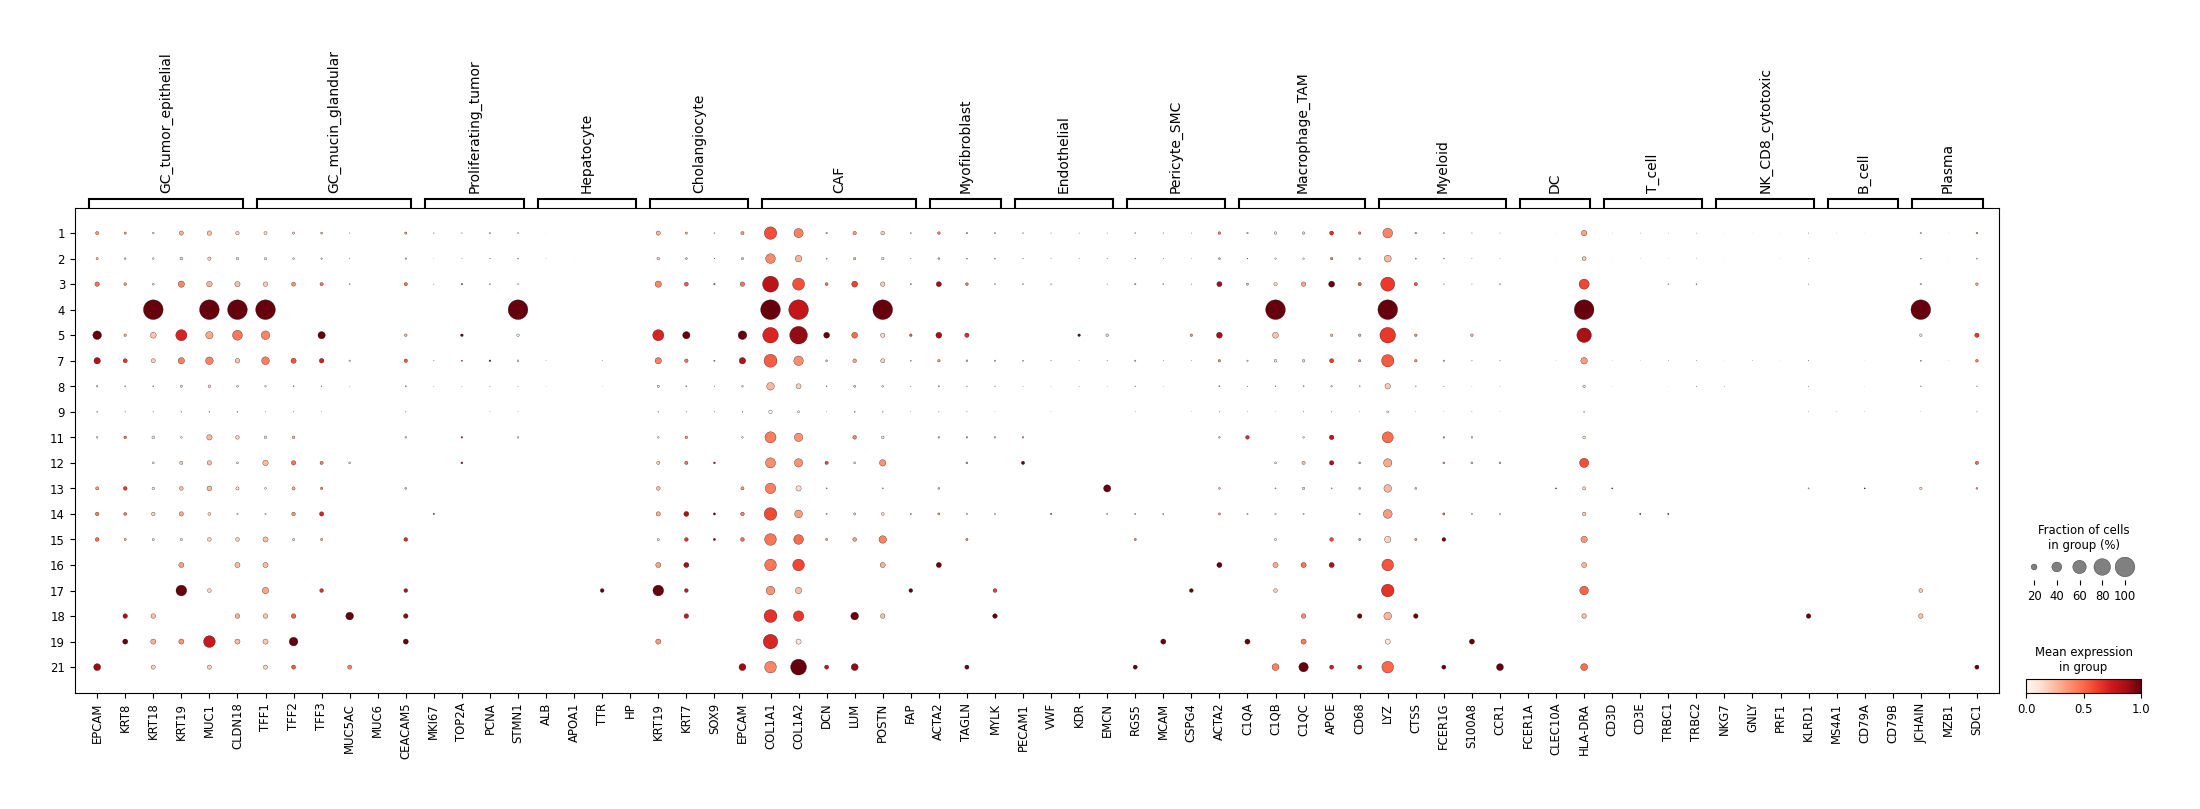

In [81]:
'''
marker_dict = {
    "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "Fibroblast": ["COL1A1", "COL1A2", "DCN", "LUM"],
    "Endothelial": ["PECAM1", "VWF", "PDGFRB" ,"CDH5"],
    "T_cell": ["CD3D", "CD3E"],
    "B_cell": ["MS4A1", "CD79A", "CD79B"],
    "Myeloid": ["LYZ", "CTSS", "FCER1G",'CCR1','CCL8'],
    "Macrophage": ["C1QA", "C1QB", "APOE"],
    "NK": ["NKG7", "GNLY", "KLRD1"],
    "Cycling": ["MKI67", "TOP2A", "PCNA"],
    'Tumor':['CLDN18']
}
'''
sc.pl.dotplot(
    adata_symbol,
    marker_dict_gc_liver_met,
    groupby="leiden",
    standard_scale="var",
    use_raw=False
)

In [63]:
adata_s1.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 7572 × 30703
    obs: 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'leiden', 'orig.ident', 'x', 'y', 'sample_by_space'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'highly_variable_rank', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'bin_size', 'bin_type', 'gene_exp_leiden', 'hvg', 'key_record', 'leiden_resolution', 'merged', 'neighbors', 'omics', 'pca_variance_ratio', 'rank_genes_groups', 'resolution', 'result_keys', 'sn', 'log1p', 'pca', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'log1p', 'counts'
    obsp: 'connectivities', 'distances'>